# Two-Model Preparatory Trajectory Comparison

This notebook compares preparatory neural trajectories between any two models (teacher-teacher, student-student, teacher-student).

Primary score: **Procrustes distance** on the trial-averaged preparatory trajectory over all 288 non-swap trials.

Secondary scores: centroid distance, sliced-Wasserstein, and MMD on preparatory state point clouds.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes
from scipy.spatial import procrustes
from scipy.stats import wasserstein_distance

from purias_utils.multiitem_working_memory.util.circle_utils import polar2cart

REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ddpm.utils.loading import generate_model_and_task_from_args_path_multiepoch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

Set each model source to either:
- `checkpoint`: load from `args.yaml` + `state.mdl`
- `array`: load precomputed trajectories from `.npy` or `.npz`

Expected array shape is `[n_trials, T_prep, D]` (or `[T_prep, D]`, which is treated as already averaged).

In [2]:
NEURAL_DIM = 16
PREP_EPOCH_INDICES = None  # None = use all preparatory epochs returned by the model
ANGLE_STEP = 30  # 2 cues x 12 x 12 = 288 trials
USE_ZSCORE = False
PCA_DIMS = 10
ALLOW_SCALING_IN_PROCRUSTES = False
N_SW_PROJECTIONS = 128
SEED = 42

MODEL_A = {
    'label': 'healthy_teacher_unablated',
    'source': 'checkpoint',
    'args_path': REPO_ROOT / 'results_link_sampler/index_cued_first_diffusion_0.3_swap_7/args.yaml',
    'checkpoint_path': REPO_ROOT / 'results_link_sampler/index_cued_first_diffusion_0.3_swap_7/state.mdl',
    'nullspace_json_path': None,
    'ablation_direction_idx': None,
    'array_path': None,
}

MODEL_B = {
    'label': 'recovery_no_ablation_0',
    'source': 'checkpoint',
    'args_path': REPO_ROOT / 'results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_ablation_no_ablation_0/args.yaml',
    'checkpoint_path': REPO_ROOT / 'results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_ablation_no_ablation_0/state.mdl',
    'nullspace_json_path': None,
    'ablation_direction_idx': None,
    'array_path': None,
}

np.random.seed(SEED)

In [3]:
def _load_single_nullspace_vector(json_path, direction_idx, device):
    with open(json_path) as f:
        data = json.load(f)
    vectors = data['nullspace_vectors']['vectors']
    sorted_keys = sorted(vectors.keys())
    key = sorted_keys[int(direction_idx)]
    vec = np.array(vectors[key], dtype=np.float32)
    return torch.tensor(vec, device=device), key


def generate_trial_combinations(angle_step=30):
    angles = list(range(0, 360, angle_step))
    trials = []
    for cue in [1, 2]:
        for color1 in angles:
            for color2 in angles:
                trials.append({
                    'cue': cue,
                    'color1_angle': color1,
                    'color2_angle': color2,
                    'swap': False,
                })
    return trials


def _extract_single_trial_prep_trajectory(trial, task, model, ablation_vector=None, neural_dim=16, prep_epoch_indices=None):
    with torch.no_grad():
        probe_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180.0)
        report_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180.0)

        override_stimulus_features = {
            'probe_features': probe_features,
            'report_features': report_features,
        }
        override_stimulus_cart_features = {
            f'{k}_cart': torch.stack(polar2cart(1.0, v), -1)
            for k, v in override_stimulus_features.items()
        }
        override_stimulus_features_dict = {
            **override_stimulus_features,
            **override_stimulus_cart_features,
            'cued_item_idx': torch.tensor([trial['cue'] - 1]),
        }

        task_variable_dict = task.task_variable_gen.generate_variable_dict(
            batch_size=1,
            override_stimulus_features_dict=override_stimulus_features_dict,
        )
        trial_info = task.generate_trial_information(
            batch_size=1,
            num_samples=1,
            override_task_variable_information=task_variable_dict,
        )

        prep_inputs = [x.to(device) if isinstance(x, torch.Tensor) else x for x in trial_info.prep_network_inputs]
        diff_inputs = [x.to(device) if isinstance(x, torch.Tensor) else x for x in trial_info.diffusion_network_inputs]

        sample_kwargs = dict(
            prep_network_inputs=prep_inputs,
            diffusion_network_inputs=diff_inputs,
            prep_epoch_durations=trial_info.prep_epoch_durations,
            diffusion_epoch_durations=trial_info.diffusion_epoch_durations,
            samples_shape=[1, 1],
            noise_scaler=1.0,
        )
        if ablation_vector is not None:
            sample_kwargs['ablation_vector'] = ablation_vector

        prep_dicts, _ = model.generate_samples(**sample_kwargs)

        if prep_epoch_indices is None:
            indices = range(len(prep_dicts))
        else:
            indices = prep_epoch_indices

        prep_segments = [
            prep_dicts[i]['preparatory_trajectory'][0, 0, :, :neural_dim].cpu().numpy().astype(np.float32)
            for i in indices
        ]
        prep_concat = np.concatenate(prep_segments, axis=0)
        return prep_concat


def _load_model_context(spec):
    _, task, model, _, _ = generate_model_and_task_from_args_path_multiepoch(str(spec['args_path']), device)
    ckpt = torch.load(spec['checkpoint_path'], map_location=device, weights_only=True)
    model.load_state_dict(ckpt)
    model.eval()

    ablation_vector = None
    ablation_key = None
    if spec.get('nullspace_json_path') is not None and spec.get('ablation_direction_idx') is not None:
        ablation_vector, ablation_key = _load_single_nullspace_vector(
            spec['nullspace_json_path'],
            spec['ablation_direction_idx'],
            device,
        )

    return task, model, ablation_vector, ablation_key


def _extract_or_load_trajectories(spec, trials, neural_dim=16, prep_epoch_indices=None):
    source = spec['source']
    if source == 'array':
        arr_path = Path(spec['array_path'])
        if arr_path.suffix == '.npy':
            arr = np.load(arr_path)
        else:
            data = np.load(arr_path)
            if 'trajectories' in data:
                arr = data['trajectories']
            else:
                first_key = list(data.keys())[0]
                arr = data[first_key]
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 2:
            arr = arr[None, :, :]
        return arr

    if source != 'checkpoint':
        raise ValueError(f"Unknown source '{source}'. Use 'checkpoint' or 'array'.")

    task, model, ablation_vector, ablation_key = _load_model_context(spec)
    if ablation_key is not None:
        print(f"[{spec['label']}] using ablation direction key: {ablation_key}")

    rows = []
    for i, trial in enumerate(trials):
        if i % 50 == 0:
            print(f"[{spec['label']}] trial {i}/{len(trials)}")
        tr = _extract_single_trial_prep_trajectory(
            trial,
            task,
            model,
            ablation_vector=ablation_vector,
            neural_dim=neural_dim,
            prep_epoch_indices=prep_epoch_indices,
        )
        rows.append(tr)

    arr = np.stack(rows, axis=0).astype(np.float32)
    return arr

In [4]:
def _joint_pca_transform(X, Y, n_components):
    if n_components is None:
        return X, Y, None
    n_components = int(min(n_components, X.shape[1], Y.shape[1]))
    if n_components < 1:
        return X, Y, None
    pca = PCA(n_components=n_components)
    pca.fit(np.vstack([X, Y]))
    return pca.transform(X), pca.transform(Y), pca


def preprocess_average_trajectories(avg_A, avg_B, use_zscore=False, pca_dims=10):
    X = avg_A.astype(np.float64)
    Y = avg_B.astype(np.float64)

    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    if use_zscore:
        x_std = X.std(axis=0, keepdims=True) + 1e-8
        y_std = Y.std(axis=0, keepdims=True) + 1e-8
        X = X / x_std
        Y = Y / y_std

    Xp, Yp, pca = _joint_pca_transform(X, Y, pca_dims)
    return Xp, Yp, pca


def procrustes_distance(X, Y, allow_scaling=False):
    if X.shape != Y.shape:
        raise ValueError(f'Shape mismatch for Procrustes: {X.shape} vs {Y.shape}')

    if allow_scaling:
        m1, m2, disparity = procrustes(X, Y)
        return {
            'distance': float(disparity),
            'aligned_ref': m1,
            'aligned_cmp': m2,
            'rotation': None,
            'mode': 'full_procrustes_with_scaling',
        }

    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    R, _ = orthogonal_procrustes(Yc, Xc)
    Y_aligned = Yc @ R

    resid = Xc - Y_aligned 
    rms_resid = float(np.sqrt(np.mean(resid ** 2)))
    rms_ref = float(np.sqrt(np.mean(Xc ** 2))) + 1e-8
    dist = rms_resid / rms_ref

    return {
        'distance': float(dist),
        'aligned_ref': Xc,
        'aligned_cmp': Y_aligned,
        'rotation': R,
        'mode': 'orthogonal_no_scaling',
    }


def centroid_distance_pointcloud(cloud_A, cloud_B):
    cA = cloud_A.mean(axis=0)
    cB = cloud_B.mean(axis=0)
    return float(np.linalg.norm(cA - cB))


def sliced_wasserstein_distance(X, Y, n_projections=128, seed=42):
    rng = np.random.default_rng(seed)
    dim = X.shape[1]
    dirs = rng.normal(size=(n_projections, dim)).astype(np.float64)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-8

    vals = []
    for v in dirs:
        vals.append(wasserstein_distance(X @ v, Y @ v))
    return float(np.mean(vals))


def rbf_mmd2(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        med = np.median(np.linalg.norm(Z[:, None, :] - Z[None, :, :], axis=2))
        gamma = 1.0 / (2.0 * (med ** 2 + 1e-8))

    XX = np.exp(-gamma * np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=2))
    YY = np.exp(-gamma * np.sum((Y[:, None, :] - Y[None, :, :]) ** 2, axis=2))
    XY = np.exp(-gamma * np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=2))

    return float(XX.mean() + YY.mean() - 2.0 * XY.mean())

In [5]:
trials = generate_trial_combinations(angle_step=ANGLE_STEP)
print(f'Generated {len(trials)} trials (expected 288).')

traj_A = _extract_or_load_trajectories(MODEL_A, trials, neural_dim=NEURAL_DIM, prep_epoch_indices=PREP_EPOCH_INDICES)
traj_B = _extract_or_load_trajectories(MODEL_B, trials, neural_dim=NEURAL_DIM, prep_epoch_indices=PREP_EPOCH_INDICES)

if traj_A.shape[1] != traj_B.shape[1]:
    raise ValueError(f'Models have different prep trajectory lengths: {traj_A.shape[1]} vs {traj_B.shape[1]}')

avg_A = traj_A.mean(axis=0)
avg_B = traj_B.mean(axis=0)

X, Y, pca = preprocess_average_trajectories(
    avg_A,
    avg_B,
    use_zscore=USE_ZSCORE,
    pca_dims=PCA_DIMS,
)

proc = procrustes_distance(X, Y, allow_scaling=ALLOW_SCALING_IN_PROCRUSTES)

cloud_A = traj_A.reshape(-1, traj_A.shape[-1]).astype(np.float64)
cloud_B = traj_B.reshape(-1, traj_B.shape[-1]).astype(np.float64)
cent_d = centroid_distance_pointcloud(cloud_A, cloud_B)
sw_d = sliced_wasserstein_distance(cloud_A, cloud_B, n_projections=N_SW_PROJECTIONS, seed=SEED)
mmd2 = rbf_mmd2(cloud_A, cloud_B)

summary = {
    'model_A': MODEL_A['label'],
    'model_B': MODEL_B['label'],
    'n_trials': int(traj_A.shape[0]),
    'prep_steps': int(traj_A.shape[1]),
    'neural_dim': int(traj_A.shape[2]),
    'procrustes_mode': proc['mode'],
    'procrustes_distance': float(proc['distance']),
    'centroid_distance_pointcloud': float(cent_d),
    'sliced_wasserstein': float(sw_d),
    'mmd2_rbf': float(mmd2),
}

print(json.dumps(summary, indent=2))

COMPARE_RESULTS = {
    'summary': summary,
    'traj_A': traj_A,
    'traj_B': traj_B,
    'avg_A': avg_A,
    'avg_B': avg_B,
    'X': X,
    'Y': Y,
    'procrustes': proc,
    'pca': pca,
}

Generated 288 trials (expected 288).
[healthy_teacher_unablated] trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE 

USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
[healthy_teacher_unablated] trial 200/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - S

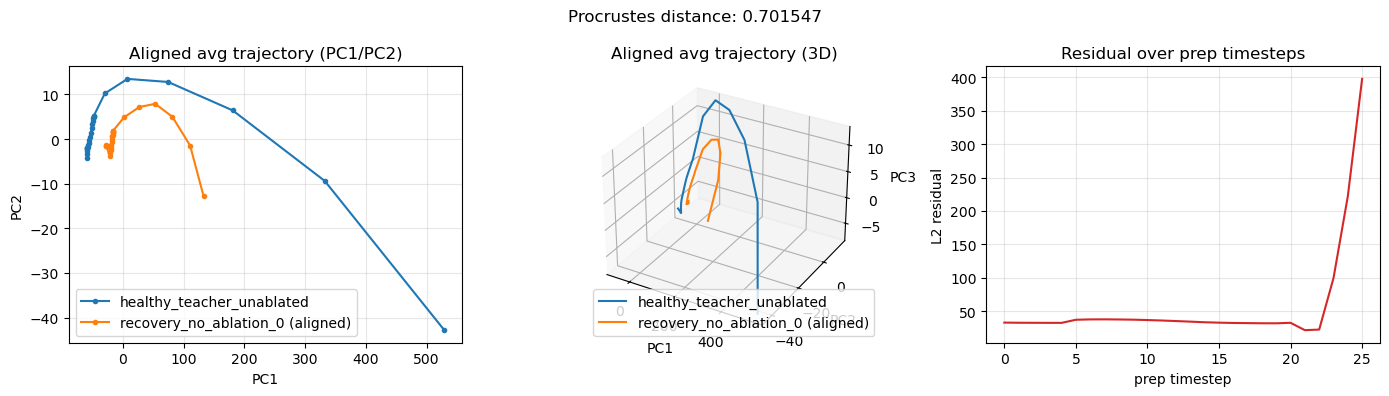

In [6]:
X_ref = COMPARE_RESULTS['procrustes']['aligned_ref']
Y_aln = COMPARE_RESULTS['procrustes']['aligned_cmp']

plot_dims = min(3, X_ref.shape[1])
fig = plt.figure(figsize=(14, 4))

if plot_dims >= 2:
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(X_ref[:, 0], X_ref[:, 1], '-o', ms=3, label=MODEL_A['label'])
    ax1.plot(Y_aln[:, 0], Y_aln[:, 1], '-o', ms=3, label=MODEL_B['label'] + ' (aligned)')
    ax1.set_title('Aligned avg trajectory (PC1/PC2)')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.legend()
    ax1.grid(alpha=0.3)

if plot_dims >= 3:
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.plot(X_ref[:, 0], X_ref[:, 1], X_ref[:, 2], label=MODEL_A['label'])
    ax2.plot(Y_aln[:, 0], Y_aln[:, 1], Y_aln[:, 2], label=MODEL_B['label'] + ' (aligned)')
    ax2.set_title('Aligned avg trajectory (3D)')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
resid_t = np.linalg.norm(X_ref - Y_aln, axis=1)
ax3.plot(np.arange(len(resid_t)), resid_t, color='tab:red')
ax3.set_title('Residual over prep timesteps')
ax3.set_xlabel('prep timestep')
ax3.set_ylabel('L2 residual')
ax3.grid(alpha=0.3)

plt.suptitle(f"Procrustes distance: {COMPARE_RESULTS['summary']['procrustes_distance']:.6f}")
plt.tight_layout()
plt.show()

## Synthetic sanity check

This quick test validates that the orthogonal Procrustes score is low when one trajectory is just a rotated + translated version of another.

In [7]:
rng = np.random.default_rng(0)
T = 80
D = 6
A = rng.normal(size=(T, D))
Q, _ = np.linalg.qr(rng.normal(size=(D, D)))
shift = rng.normal(size=(1, D))
B = A @ Q + shift + 0.02 * rng.normal(size=(T, D))

X_syn, Y_syn, _ = preprocess_average_trajectories(A, B, use_zscore=False, pca_dims=None)
syn_proc = procrustes_distance(X_syn, Y_syn, allow_scaling=False)
print('Synthetic Procrustes distance (should be small):', syn_proc['distance'])

Synthetic Procrustes distance (should be small): 0.018130269438891615


## Batch: Healthy vs All Teacher Ablations

This section compares the healthy teacher (`index_cued_first_diffusion_0.3_swap_7`) against all ablation directions from the same checkpoint.

It saves a score table (including Procrustes distance) to CSV so you can record it.

In [8]:
import pandas as pd


def _compute_metric_bundle(traj_A, traj_B, label_A, label_B, seed=42):
    if traj_A.shape[1] != traj_B.shape[1]:
        raise ValueError(
            f"Trajectory length mismatch: {traj_A.shape[1]} vs {traj_B.shape[1]}"
        )

    avg_A = traj_A.mean(axis=0)
    avg_B = traj_B.mean(axis=0)
    X, Y, _ = preprocess_average_trajectories(
        avg_A,
        avg_B,
        use_zscore=USE_ZSCORE,
        pca_dims=PCA_DIMS,
    )
    proc = procrustes_distance(X, Y, allow_scaling=ALLOW_SCALING_IN_PROCRUSTES)

    cloud_A = traj_A.reshape(-1, traj_A.shape[-1]).astype(np.float64)
    cloud_B = traj_B.reshape(-1, traj_B.shape[-1]).astype(np.float64)

    return {
        "model_A": label_A,
        "model_B": label_B,
        "n_trials": int(traj_A.shape[0]),
        "prep_steps": int(traj_A.shape[1]),
        "neural_dim": int(traj_A.shape[2]),
        "procrustes_mode": proc["mode"],
        "procrustes_distance": float(proc["distance"]),
        "centroid_distance_pointcloud": float(centroid_distance_pointcloud(cloud_A, cloud_B)),
        "sliced_wasserstein": float(
            sliced_wasserstein_distance(
                cloud_A,
                cloud_B,
                n_projections=N_SW_PROJECTIONS,
                seed=seed,
            )
        ),
        "mmd2_rbf": float(rbf_mmd2(cloud_A, cloud_B)),
    }


def run_healthy_vs_all_teacher_ablations(
    healthy_run_dir="index_cued_first_diffusion_0.3_swap_7",
    n_directions=14,
    output_dir=None,
    direction_indices=None,
):
    if direction_indices is None:
        direction_indices = list(range(n_directions))

    root = REPO_ROOT / "results_link_sampler" / healthy_run_dir
    args_path = root / "args.yaml"
    checkpoint_path = root / "state.mdl"
    nullspace_json_path = root / "nullspace_and_projection.json"

    healthy_spec = {
        "label": f"{healthy_run_dir}_healthy",
        "source": "checkpoint",
        "args_path": args_path,
        "checkpoint_path": checkpoint_path,
        "nullspace_json_path": None,
        "ablation_direction_idx": None,
        "array_path": None,
    }

    trials = generate_trial_combinations(angle_step=ANGLE_STEP)
    print(f"Generated {len(trials)} trials.")

    print("Extracting healthy trajectories once...")
    healthy_traj = _extract_or_load_trajectories(
        healthy_spec,
        trials,
        neural_dim=NEURAL_DIM,
        prep_epoch_indices=PREP_EPOCH_INDICES,
    )

    rows = []
    for di in direction_indices:
        print("=" * 70)
        print(f"Comparing healthy vs ablation direction {di}")
        ablated_spec = {
            "label": f"{healthy_run_dir}_ablated_dir_{int(di):02d}",
            "source": "checkpoint",
            "args_path": args_path,
            "checkpoint_path": checkpoint_path,
            "nullspace_json_path": nullspace_json_path,
            "ablation_direction_idx": int(di),
            "array_path": None,
        }

        ablated_traj = _extract_or_load_trajectories(
            ablated_spec,
            trials,
            neural_dim=NEURAL_DIM,
            prep_epoch_indices=PREP_EPOCH_INDICES,
        )

        bundle = _compute_metric_bundle(
            healthy_traj,
            ablated_traj,
            label_A=healthy_spec["label"],
            label_B=ablated_spec["label"],
            seed=SEED + int(di),
        )
        bundle["ablation_direction_idx"] = int(di)
        rows.append(bundle)

    df = pd.DataFrame(rows).sort_values("procrustes_distance", ascending=False)

    if output_dir is None:
        output_dir = REPO_ROOT / "ddpm" / "analysis" / "new_analysis" / "results" / "healthy_vs_ablations"
    else:
        output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    out_csv = output_dir / "healthy_vs_teacher_ablations_scores.csv"
    df.to_csv(out_csv, index=False)

    print(f"Saved score table: {out_csv}")
    print("Top 5 by Procrustes distance:")
    print(df[["ablation_direction_idx", "procrustes_distance"]].head(5).to_string(index=False))

    return df, out_csv


# Set RUN_HEALTHY_VS_ALL_ABLATIONS=True to execute the full 14-direction batch.
RUN_HEALTHY_VS_ALL_ABLATIONS = True

if RUN_HEALTHY_VS_ALL_ABLATIONS:
    scores_df, scores_csv_path = run_healthy_vs_all_teacher_ablations()
    display(scores_df)
else:
    print("Batch function ready.")
    print("Set RUN_HEALTHY_VS_ALL_ABLATIONS=True and run this cell to compute and save scores.")

Generated 288 trials.
Extracting healthy trajectories once...
[index_cued_first_diffusion_0.3_swap_7_healthy] trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAININ

USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PREC

,model_A,model_B,n_trials,prep_steps,neural_dim,procrustes_mode,procrustes_distance,centroid_distance_pointcloud,sliced_wasserstein,mmd2_rbf,ablation_direction_idx
0,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.538497,41.259582,9.340670,0.026447,0
12,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.445413,39.278244,9.172585,0.013603,12
7,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.242658,19.439199,4.851920,0.001235,7
11,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.216758,26.377392,5.591406,0.010355,11
8,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.137583,13.902588,3.163169,0.000238,8
3,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.080313,16.882291,3.761299,0.014290,3
4,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.059762,20.037191,4.279599,0.005163,4
10,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.029458,13.703617,2.635532,0.016088,10
5,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.026203,4.589975,1.754583,0.002351,5
13,index_cued_first_diffusion_0.3_swap_7_healthy,index_cued_first_diffusion_0.3_swap_7_ablated_...,288,26,16,orthogonal_no_scaling,0.025442,2.783002,1.483545,0.002627,13


In [9]:
# Ensure helper _compute_metric_bundle is defined in this kernel (re-define if missing)
import pandas as pd

def _compute_metric_bundle(traj_A, traj_B, label_A, label_B, seed=42):
    if traj_A.shape[1] != traj_B.shape[1]:
        raise ValueError(f"Trajectory length mismatch: {traj_A.shape[1]} vs {traj_B.shape[1]}")

    avg_A = traj_A.mean(axis=0)
    avg_B = traj_B.mean(axis=0)
    X, Y, _ = preprocess_average_trajectories(avg_A, avg_B, use_zscore=USE_ZSCORE, pca_dims=PCA_DIMS)
    proc = procrustes_distance(X, Y, allow_scaling=ALLOW_SCALING_IN_PROCRUSTES)

    cloud_A = traj_A.reshape(-1, traj_A.shape[-1]).astype(np.float64)
    cloud_B = traj_B.reshape(-1, traj_B.shape[-1]).astype(np.float64)

    return {
        'model_A': label_A,
        'model_B': label_B,
        'n_trials': int(traj_A.shape[0]),
        'prep_steps': int(traj_A.shape[1]),
        'neural_dim': int(traj_A.shape[2]),
        'procrustes_mode': proc['mode'],
        'procrustes_distance': float(proc['distance']),
        'centroid_distance_pointcloud': float(centroid_distance_pointcloud(cloud_A, cloud_B)),
        'sliced_wasserstein': float(sliced_wasserstein_distance(cloud_A, cloud_B, n_projections=N_SW_PROJECTIONS, seed=seed)),
        'mmd2_rbf': float(rbf_mmd2(cloud_A, cloud_B)),
    }

print('_compute_metric_bundle defined/re-defined')

_compute_metric_bundle defined/re-defined


In [10]:
# Batch: Compare each ablated teacher direction to a set of student runs
import pandas as pd

STUDENT_RUNS = [
    'index_cued_first_diffusion_0.3_swap_recovery_ablation_0_0',
    'index_cued_first_diffusion_0.3_swap_recovery_ablation_1_0',
    'index_cued_first_diffusion_0.3_swap_recovery_ablation_4_0',
    'index_cued_first_diffusion_0.3_swap_recovery_ablation_5_0',
    'index_cued_first_diffusion_0.3_swap_recovery_ablation_6_0',
    'index_cued_first_diffusion_0.3_swap_ablation_7_1',
]


def compare_ablation_dirs_to_students(
    teacher_root_dir='index_cued_first_diffusion_0.3_swap_7',
    student_runs=STUDENT_RUNS,
    direction_indices=None,
    output_dir=None,
):
    if direction_indices is None:
        direction_indices = list(range(14))

    teacher_root = REPO_ROOT / 'results_link_sampler' / teacher_root_dir
    args_path = teacher_root / 'args.yaml'
    ckpt_path = teacher_root / 'state.mdl'
    nullspace_json_path = teacher_root / 'nullspace_and_projection.json'

    trials = generate_trial_combinations(angle_step=ANGLE_STEP)

    # Preload student trajectories
    student_trajs = {}
    for s in student_runs:
        print(f'Loading student run: {s}')
        sroot = REPO_ROOT / 'results_link_sampler' / s
        spec = {
            'label': s,
            'source': 'checkpoint',
            'args_path': sroot / 'args.yaml',
            'checkpoint_path': sroot / 'state.mdl',
            'nullspace_json_path': None,
            'ablation_direction_idx': None,
            'array_path': None,
        }
        student_trajs[s] = _extract_or_load_trajectories(spec, trials, neural_dim=NEURAL_DIM, prep_epoch_indices=PREP_EPOCH_INDICES)

    rows = []
    for di in direction_indices:
        print('\n' + '='*70)
        print(f'Processing ablation direction {di}')
        ablated_spec = {
            'label': f'{teacher_root_dir}_ablated_dir_{int(di):02d}',
            'source': 'checkpoint',
            'args_path': args_path,
            'checkpoint_path': ckpt_path,
            'nullspace_json_path': nullspace_json_path,
            'ablation_direction_idx': int(di),
            'array_path': None,
        }
        ablated_traj = _extract_or_load_trajectories(ablated_spec, trials, neural_dim=NEURAL_DIM, prep_epoch_indices=PREP_EPOCH_INDICES)

        for s, st_traj in student_trajs.items():
            print(f'  Comparing ablation {di} -> student {s}')
            bundle = _compute_metric_bundle(ablated_traj, st_traj, label_A=ablated_spec['label'], label_B=s, seed=SEED + int(di))
            bundle['ablation_direction_idx'] = int(di)
            bundle['student_run'] = s
            rows.append(bundle)

    df = pd.DataFrame(rows)
    if output_dir is None:
        output_dir = REPO_ROOT / 'ddpm' / 'analysis' / 'new_analysis' / 'results' / 'ablations_vs_students'
    else:
        output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    out_csv = output_dir / 'ablations_vs_students_scores.csv'
    df.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')
    return df, out_csv

# Execute now
RUN_ABLATIONS_VS_STUDENTS = True
if RUN_ABLATIONS_VS_STUDENTS:
    df_ab_st, csv_ab_st = compare_ablation_dirs_to_students()
    display(df_ab_st.head())
else:
    print('Function compare_ablation_dirs_to_students defined. Set RUN_ABLATIONS_VS_STUDENTS=True to run.')

Loading student run: index_cued_first_diffusion_0.3_swap_recovery_ablation_0_0
[index_cued_first_diffusion_0.3_swap_recovery_ablation_0_0] trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SH

,model_A,model_B,n_trials,prep_steps,neural_dim,procrustes_mode,procrustes_distance,centroid_distance_pointcloud,sliced_wasserstein,mmd2_rbf,ablation_direction_idx,student_run
0,index_cued_first_diffusion_0.3_swap_7_ablated_...,index_cued_first_diffusion_0.3_swap_recovery_a...,288,26,16,orthogonal_no_scaling,0.627566,29.428424,9.640285,0.178009,0,index_cued_first_diffusion_0.3_swap_recovery_a...
1,index_cued_first_diffusion_0.3_swap_7_ablated_...,index_cued_first_diffusion_0.3_swap_recovery_a...,288,26,16,orthogonal_no_scaling,0.597386,53.329056,12.052540,0.204123,0,index_cued_first_diffusion_0.3_swap_recovery_a...
2,index_cued_first_diffusion_0.3_swap_7_ablated_...,index_cued_first_diffusion_0.3_swap_recovery_a...,288,26,16,orthogonal_no_scaling,0.585244,24.005525,8.721622,0.152486,0,index_cued_first_diffusion_0.3_swap_recovery_a...
3,index_cued_first_diffusion_0.3_swap_7_ablated_...,index_cued_first_diffusion_0.3_swap_recovery_a...,288,26,16,orthogonal_no_scaling,0.373445,18.231382,5.943772,0.081094,0,index_cued_first_diffusion_0.3_swap_recovery_a...
4,index_cued_first_diffusion_0.3_swap_7_ablated_...,index_cued_first_diffusion_0.3_swap_recovery_a...,288,26,16,orthogonal_no_scaling,1.151048,161.365487,32.902797,0.416718,0,index_cued_first_diffusion_0.3_swap_recovery_a...
